In [1]:
# Cell 1 — project path setup

import sys
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [2]:
# Cell 2 — imports

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.loaders import load_function
from src.utils import get_best_point, get_top_points, format_query

In [3]:
# Cell 3 — choose the week

week_num = 13
data_root = Path(rf"D:\Capstone_BBO\data\week_{week_num}")

print(rf"Working on Week {week_num}")
print("Data folder:", data_root.resolve())

Working on Week 13
Data folder: D:\Capstone_BBO\data\week_13


In [4]:
# Cell 4 — load all 8 functions automatically

functions_data = {}

for fn in range(1, 9):
    function_folder = data_root / f"function_{fn}"
    inputs_path = function_folder / "initial_inputs.npy"
    outputs_path = function_folder / "initial_outputs.npy"

    X, y = load_function(inputs_path, outputs_path)

    functions_data[fn] = {
        "folder": function_folder,
        "inputs_path": inputs_path,
        "outputs_path": outputs_path,
        "X": X,
        "y": y
    }

print("Loaded functions:", list(functions_data.keys()))

Loaded functions: [1, 2, 3, 4, 5, 6, 7, 8]


In [5]:
# Cell 5 — quick overview of all functions

overview_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    overview_rows.append({
        "function": fn,
        "n_points": X.shape[0],
        "dimension": X.shape[1],
        "y_min": float(np.min(y)),
        "y_max": float(np.max(y)),
        "y_mean": float(np.mean(y)),
        "y_std": float(np.std(y))
    })

overview_df = pd.DataFrame(overview_rows)
overview_df

,function,n_points,dimension,y_min,y_max,y_mean,y_std
0,1,11,2,-0.003606,7.710875e-16,-0.000328,0.001037
1,2,11,2,-0.065624,6.464088e-01,0.268468,0.245878
2,3,16,3,-0.398926,-3.483531e-02,-0.103216,0.082963
3,4,31,4,-32.625660,-4.025542e+00,-16.812361,7.287895
4,5,21,4,0.112940,1.088860e+03,195.918843,311.933980
5,6,21,5,-2.571170,-7.063869e-01,-1.457818,0.469290
6,7,31,6,0.002701,1.364970e+00,0.256554,0.359570
7,8,41,8,5.592193,9.598482e+00,7.858767,0.974896


In [6]:
# Cell 6 — best point for each function

best_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    best_rows.append({
        "function": fn,
        "best_index": int(best_idx),
        "best_output": float(best_y),
        "best_point": best_x,
        "formatted_best_point": format_query(best_x)
    })

best_df = pd.DataFrame(best_rows)
best_df

,function,best_index,best_output,best_point,formatted_best_point
0,1,2,7.710875e-16,"[0.7310236309563586, 0.7329998764152272]",0.731024-0.733000
1,2,10,6.464088e-01,"[0.702637, 0.926564]",0.702637-0.926564
2,3,3,-3.483531e-02,"[0.49258141463713434, 0.6115931882759961, 0.34...",0.492581-0.611593-0.340176
3,4,27,-4.025542e+00,"[0.5777656143780968, 0.4287717415443063, 0.425...",0.577766-0.428772-0.425826-0.249007
4,5,15,1.088860e+03,"[0.22418902330288348, 0.8464804904862864, 0.87...",0.224189-0.846480-0.879484-0.878516
5,6,20,-7.063869e-01,"[0.728186, 0.154693, 0.732552, 0.693997, 0.056...",0.728186-0.154693-0.732552-0.693997-0.056401
6,7,30,1.364970e+00,"[0.057896, 0.491672, 0.247422, 0.218118, 0.420...",0.057896-0.491672-0.247422-0.218118-0.420428-0...
7,8,40,9.598482e+00,"[0.056447, 0.065956, 0.022929, 0.038786, 0.403...",0.056447-0.065956-0.022929-0.038786-0.403935-0...


In [7]:
# Cell 7 — top 5 points for a chosen function

# This lets you inspect one function in detail without changing paths.
inspect_function = 3

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

top_idx, top_X, top_y = get_top_points(X, y, top_n=5)

col_names = [f"x{i+1}" for i in range(X.shape[1])]
top_df = pd.DataFrame(top_X, columns=col_names)
top_df["y"] = top_y
top_df["original_index"] = top_idx

print(f"Top 5 points for Function {inspect_function}")
top_df

Top 5 points for Function 3


,x1,x2,x3,y,original_index
0,0.492581,0.611593,0.340176,-0.034835,3
1,0.600097,0.725136,0.066089,-0.036378,13
2,0.492581,0.611593,0.340176,-0.043951,15
3,0.220549,0.297825,0.343555,-0.046947,10
4,0.134622,0.219917,0.458206,-0.048008,4


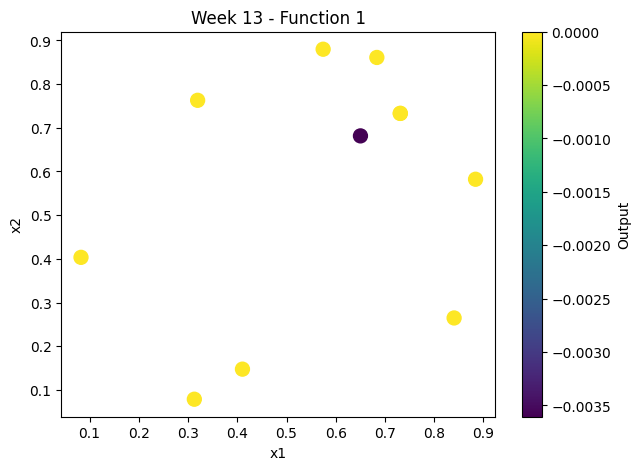

In [8]:
#Cell 9 — create initial candidate table

# This gives you a starting point for all 8 functions.

# For now, the initial candidate is just the current best point. Later we will improve this.

inspect_function = 1

X = functions_data[inspect_function]["X"]
y = functions_data[inspect_function]["y"]

if X.shape[1] == 2:
    plt.figure(figsize=(7,5))
    sc = plt.scatter(X[:, 0], X[:, 1], c=y, s=100)
    plt.colorbar(sc, label="Output")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Week {week_num} - Function {inspect_function}")
    plt.show()
else:
    print(f"Function {inspect_function} is {X.shape[1]}D, so no simple 2D scatter plot.")

In [12]:
manual_candidates = {
    1: None,
    2: None,
    3: None,
    4: None,
    5: None,
    6: None,
    7: None,
    8: None
}

In [13]:
np.random.seed(42)

auto_candidates = {}

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    top_idx, top_X, top_y = get_top_points(X, y, top_n=min(3, len(y)))
    dim = X.shape[1]

    # Choose one of the top points as anchor
    anchor = top_X[0].copy()

    # Perturbation size
    step = 0.03 if dim <= 4 else 0.02

    # Number of coordinates to perturb
    n_change = 2 if dim >= 5 else max(1, dim // 2)
    n_change = min(n_change, dim)

    candidate = anchor.copy()

    change_idx = np.random.choice(dim, size=n_change, replace=False)
    noise = np.random.uniform(-step, step, size=n_change)

    candidate[change_idx] = candidate[change_idx] + noise
    candidate = np.clip(candidate, 0, 1)

    auto_candidates[fn] = candidate

auto_candidates

{1: array([0.73102363, 0.75079246]),
 2: array([0.702637  , 0.94048364]),
 3: array([0.49258141, 0.59095431, 0.34017639]),
 4: array([0.56778813, 0.42632668, 0.42582587, 0.24900741]),
 5: array([0.19757372, 0.85980042, 0.87948418, 0.87851568]),
 6: array([0.728186  , 0.154693  , 0.73354226, 0.693997  , 0.04857069]),
 7: array([0.057896  , 0.48766644, 0.247422  , 0.218118  , 0.420428  ,
        0.71283663]),
 8: array([0.06014358, 0.04781402, 0.022929  , 0.038786  , 0.403935  ,
        0.801055  , 0.488307  , 0.893085  ])}

In [15]:
submission_rows = []

for fn, data in functions_data.items():
    X = data["X"]
    y = data["y"]

    best_idx, best_x, best_y = get_best_point(X, y)

    # Use manual candidate only if you explicitly set one
    chosen_candidate = manual_candidates.get(fn)

    # Otherwise use the auto-generated candidate
    if chosen_candidate is None:
        chosen_candidate = auto_candidates[fn]

    chosen_candidate = np.array(chosen_candidate, dtype=float)
    chosen_candidate = np.clip(chosen_candidate, 0, 1)

    already_exists = np.any(np.all(np.isclose(X, chosen_candidate, atol=1e-12), axis=1))

    submission_rows.append({
        "function": fn,
        "dimension": X.shape[1],
        "best_output_so_far": float(best_y),
        "best_point_so_far": format_query(best_x),
        "chosen_candidate_array": chosen_candidate,
        "query": format_query(chosen_candidate),
        "already_exists": bool(already_exists)
    })

submission_df = pd.DataFrame(submission_rows)
submission_df

,function,dimension,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists
0,1,2,7.710875e-16,0.731024-0.733000,"[0.7310236309563586, 0.7507924556268412]",0.731024-0.750792,False
1,2,2,6.464088e-01,0.702637-0.926564,"[0.702637, 0.9404836365086844]",0.702637-0.940484,False
2,3,3,-3.483531e-02,0.492581-0.611593-0.340176,"[0.49258141463713434, 0.5909543067025422, 0.34...",0.492581-0.590954-0.340176,False
3,4,4,-4.025542e+00,0.577766-0.428772-0.425826-0.249007,"[0.5677881310464381, 0.42632667506225835, 0.42...",0.567788-0.426327-0.425826-0.249007,False
4,5,4,1.088860e+03,0.224189-0.846480-0.879484-0.878516,"[0.1975737180445095, 0.8598004168222959, 0.879...",0.197574-0.859800-0.879484-0.878516,False
5,6,5,-7.063869e-01,0.728186-0.154693-0.732552-0.693997-0.056401,"[0.728186, 0.154693, 0.7335422572652895, 0.693...",0.728186-0.154693-0.733542-0.693997-0.048571,False
6,7,6,1.364970e+00,0.057896-0.491672-0.247422-0.218118-0.420428-0...,"[0.057896, 0.4876664388686102, 0.247422, 0.218...",0.057896-0.487666-0.247422-0.218118-0.420428-0...,False
7,8,8,9.598482e+00,0.056447-0.065956-0.022929-0.038786-0.403935-0...,"[0.0601435827544817, 0.047814016508799906, 0.0...",0.060144-0.047814-0.022929-0.038786-0.403935-0...,False


In [16]:
repeated_df = submission_df[submission_df["already_exists"] == True]
repeated_df

,function,dimension,best_output_so_far,best_point_so_far,chosen_candidate_array,query,already_exists


In [17]:
submission_export = submission_df[["function", "query"]].copy()

output_file = Path(rf"D:\Capstone_BBO\submissiones\week_{week_num}_submission.csv")
submission_export.to_csv(output_file, index=False)

print("Saved submission file to:", output_file.resolve())
submission_export

Saved submission file to: D:\Capstone_BBO\submissiones\week_13_submission.csv


,function,query
0,1,0.731024-0.750792
1,2,0.702637-0.940484
2,3,0.492581-0.590954-0.340176
3,4,0.567788-0.426327-0.425826-0.249007
4,5,0.197574-0.859800-0.879484-0.878516
5,6,0.728186-0.154693-0.733542-0.693997-0.048571
6,7,0.057896-0.487666-0.247422-0.218118-0.420428-0...
7,8,0.060144-0.047814-0.022929-0.038786-0.403935-0...
